# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [ ]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.2/481.2 kB 16.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.3 which is incompatible.
google-adk 1.29.0 requires requests<3.0.0,>=2.32.4, but you have requests 2.32.3 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.30.1 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.30.1 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have hugging

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [52]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

from sklearn import metrics

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/SuperKart/SuperKart.csv')

Mounted at /content/drive


# **Data Overview**

In [3]:
data.shape

(8763, 12)

* Data contains 8763 rows and 12 columns

In [4]:
data.head()


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


*  After looking at the first 5 rows of the data, it contains different information regarding the products, like sugar contects are low, regular, Product type dairy, frozen, Product MRP, etc.
*  Product Allocated area looks numeric and odd. It contains the 3 digit after decimal which do not tell any information regarding area.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


*  There are 6 categorial Columns excluding production id column.
*  There are 5 numerical columns.

In [6]:
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


*  Looks like there is no data missing in the given set.

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


Observations:

*   Average Sales for stores is 1065.
*   Average MRP for the product is approximatly 30.



# **Exploratory Data Analysis (EDA)**

In [35]:
# Define the target variable for the regression task
target = 'Product_Store_Sales_Total'

# List of numerical features in the dataset (excluding 'id' as it is an identifier)
numeric_features = [
    'Product_Weight',         # Product Weight
    'Product_Allocated_Area',            # Allocated Area
    'Product_MRP', # Product MRP
    'Store_Establishment_Year',             # Establishment Year

]

# List of categorical features in the dataset
categorical_features = [
    'Product_Sugar_Content',             # Product Sugar Content
    'Product_Type',   # Product Type
    'Store_Id',          # Store Id
    'Store_Size',       # Store Size
    'Store_Location_City_Type',  #Location City Type
    'Store_Type'   #Store Type
]

## Univariate Analysis

In [8]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [9]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

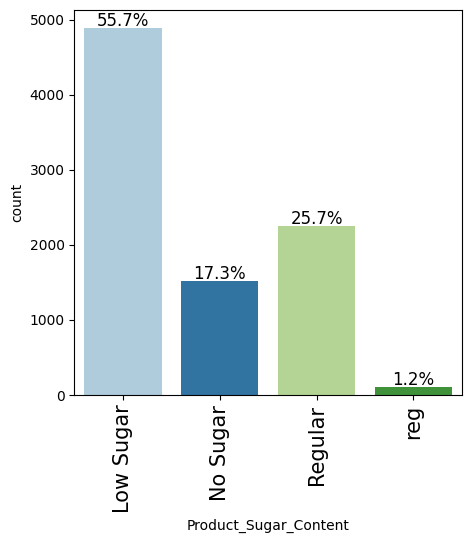

In [10]:
labeled_barplot(data,"Product_Sugar_Content",perc=True)

*  There are almost 55% of the product contains low sugar.
*  reg might be regular which was shorten as "reg.
*  Lowest of all is No sugar products which are approximatly 17%.

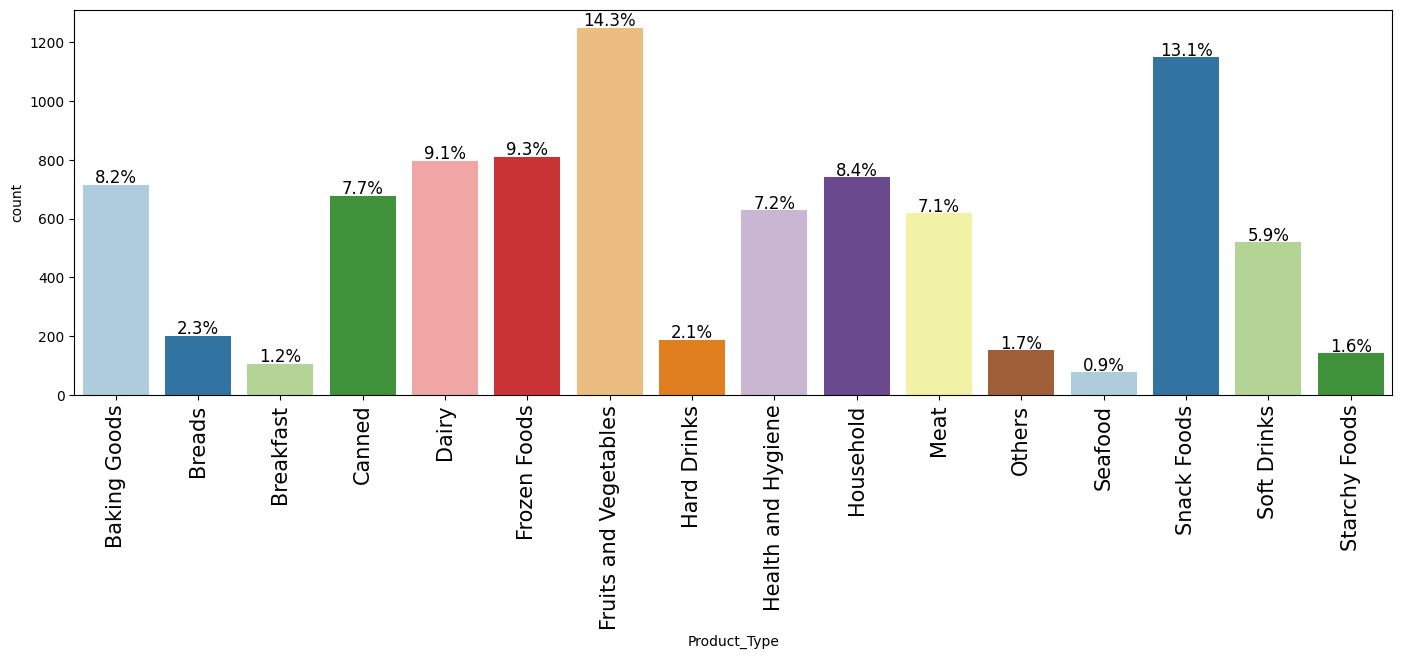

In [11]:
labeled_barplot(data,"Product_Type",perc=True)

*  Hightest contribution of the product type contains Fruits and Vegetables which is almost 14%.
*  The lowest of all is seafood which is just 0.9%.
*  Snacks food are on the 2nd highest right at 13%.

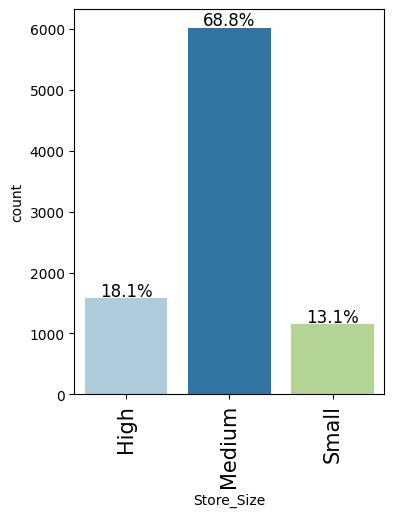

In [12]:
labeled_barplot(data,"Store_Size",perc=True)

*  Medium size stores are highest in the give set of data. It contribute to 69%.
*  Small and High contribute to 18 & 13 percentage respectivly.


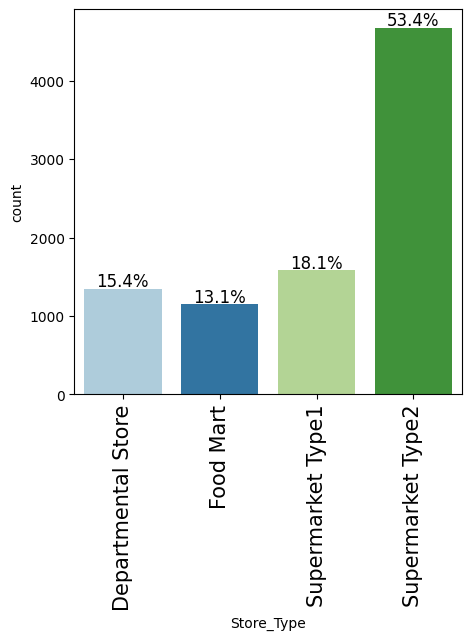

In [13]:
labeled_barplot(data,"Store_Type",perc=True)

*  Supertmarket Type2 selss hightest product among all the other stores around 53%
*  Food Mart at the bottom of all with 13%.

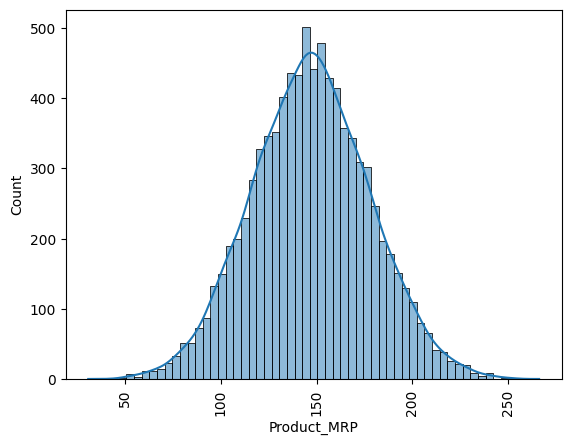

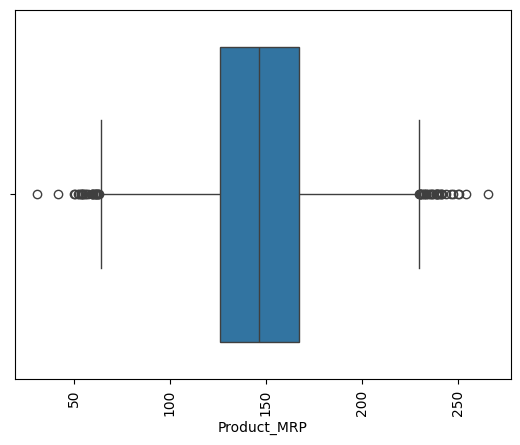

In [14]:
ax = sns.histplot(data =data,x='Product_MRP',kde= True);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
plt.show()
x = sns.boxplot(data = data, x ='Product_MRP');
x.set_xticklabels(x.get_xticklabels(), rotation=90);
plt.show()

*  There are outliers both the side for Product MRP.
*  Product MRP data is symetrically skewed.
*  Average MRP price is aorund 140.

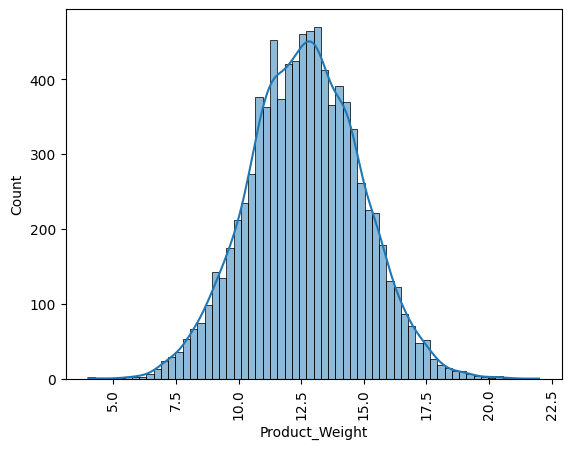

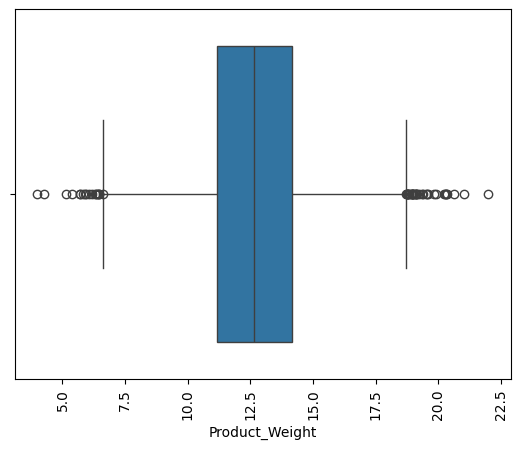

In [15]:
ax = sns.histplot(data =data,x='Product_Weight',kde= True);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
plt.show()
x = sns.boxplot(data = data, x ='Product_Weight');
x.set_xticklabels(x.get_xticklabels(), rotation=90);
plt.show()

*  There are outliers both the side for Product Weight.
*  Product Weight data is symetrically skewed.
*  Average weight of the product is 12.5

## Bivariate Analysis

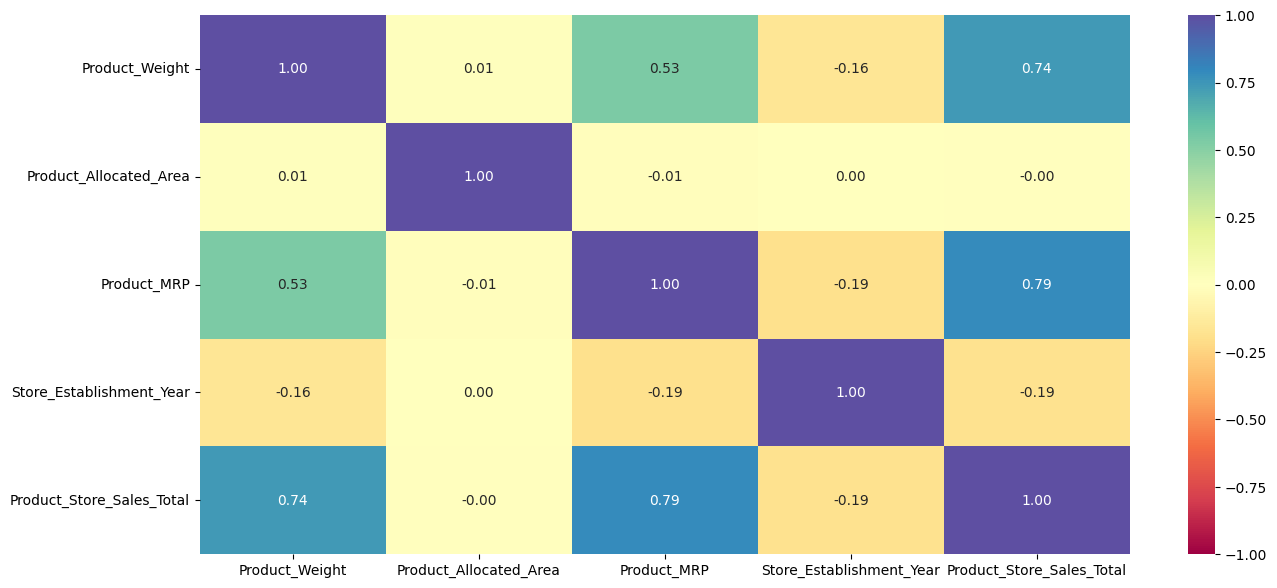

In [16]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize = (15,7))
sns.heatmap(data[cols_list].corr(), annot = True, vmin = -1, vmax =1, fmt = '.2f',cmap="Spectral")
plt.show()

**Observations:**

*   Product Store Sales is in positive correlation with Product weight and Prodcut MRP.
*   Product MRP is in positive correlation with Product weight.
*   Product Store Sales is in negative correlation with Store estabilishment year.



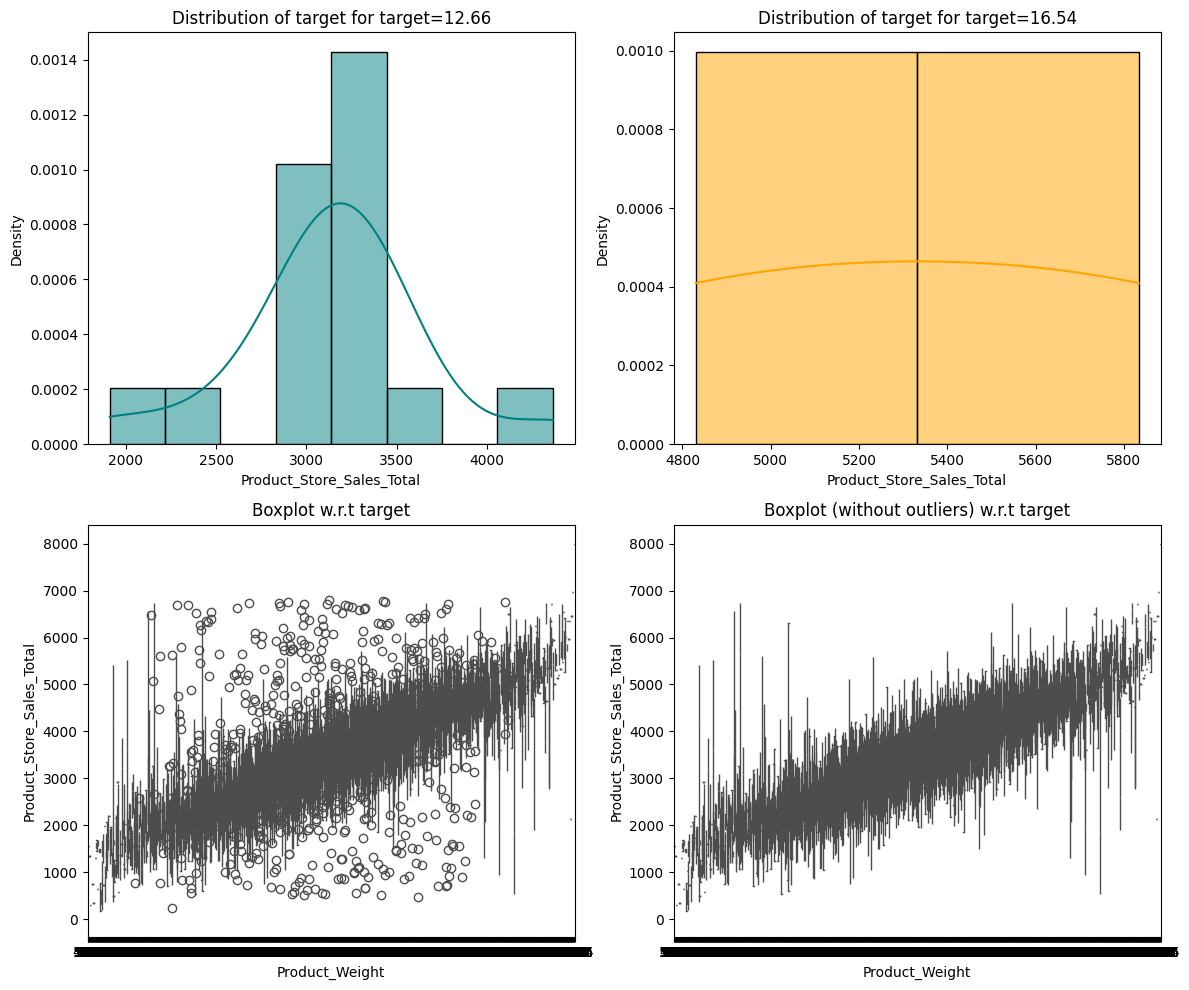

In [17]:
distribution_plot_wrt_target(data,"Product_Store_Sales_Total","Product_Weight")

* It is very difficult to figure out from this graph as there are lots of different product weight. but there are some outliers in it which is understandable as the prices will get vary for different prodict weight.

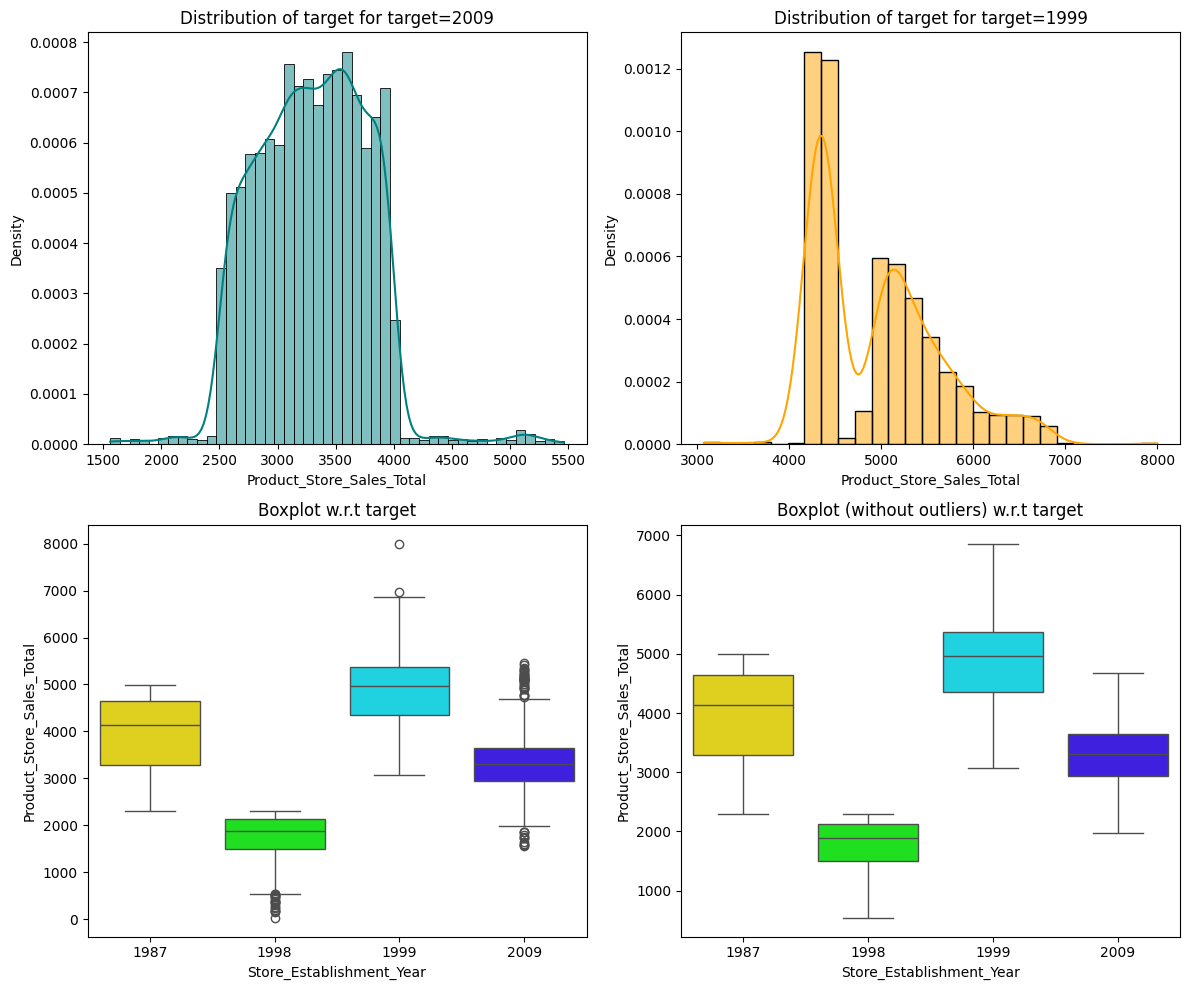

In [18]:
distribution_plot_wrt_target(data,"Product_Store_Sales_Total","Store_Establishment_Year")

* Product sales is decreases as the estabilishment year increassed. In 1987 the average total sales was 4100 and in year 2009 it decreased to 3200.

# **Data Preprocessing**

In [19]:
data["Product_Sugar_Content"].unique()

array(['Low Sugar', 'Regular', 'No Sugar', 'reg'], dtype=object)

* There is extra sugar content called 'reg' which looks like abbrivation of Regular.

In [20]:
data[data['Product_Sugar_Content']=='reg']

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
43,DR2126,7.82,reg,0.036,Hard Drinks,102.18,OUT002,1998,Small,Tier 3,Food Mart,1443.06
87,FD5746,11.59,reg,0.091,Dairy,145.79,OUT004,2009,Medium,Tier 2,Supermarket Type2,3188.61
118,FD3884,11.72,reg,0.102,Baking Goods,143.79,OUT004,2009,Medium,Tier 2,Supermarket Type2,3175.51
134,FD1368,16.29,reg,0.184,Frozen Foods,217.94,OUT003,1999,Medium,Tier 1,Departmental Store,5726.19
143,FD8450,14.08,reg,0.074,Breads,127.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,3375.71
...,...,...,...,...,...,...,...,...,...,...,...,...
8037,FD4281,14.56,reg,0.105,Baking Goods,180.21,OUT001,1987,High,Tier 2,Supermarket Type1,4562.36
8076,FD5788,11.62,reg,0.054,Canned,136.42,OUT004,2009,Medium,Tier 2,Supermarket Type2,3001.97
8185,FD8547,11.80,reg,0.029,Breads,144.64,OUT004,2009,Medium,Tier 2,Supermarket Type2,3212.19
8211,FD8751,12.75,reg,0.056,Fruits and Vegetables,227.47,OUT003,1999,Medium,Tier 1,Departmental Store,5120.87


*  There are almost 108 rows which has the Sugar content as reg.
*  We can replace reg with Regular.

Lets replace reg with Regular.

In [21]:
data_copy = data.copy()
data_copy['Product_Sugar_Content'] = data_copy['Product_Sugar_Content'].replace('reg','Regular')
data_copy['Product_Sugar_Content'].unique()

array(['Low Sugar', 'Regular', 'No Sugar'], dtype=object)

In [22]:
data["Store_Establishment_Year"].unique()

array([2009, 1999, 1987, 1998])

In [23]:
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


In [24]:
data["Store_Id"].unique()

array(['OUT004', 'OUT003', 'OUT001', 'OUT002'], dtype=object)

In [25]:
data["Store_Size"].unique()

array(['Medium', 'High', 'Small'], dtype=object)

In [26]:
data["Store_Type"].unique()

array(['Supermarket Type2', 'Departmental Store', 'Supermarket Type1',
       'Food Mart'], dtype=object)

Lets drop the id column which is continues variable and won't be useful in our model building

In [27]:
data_copy.drop("Product_Id",axis = 1, inplace = True)

In [28]:
X = data_copy.drop("Product_Store_Sales_Total",axis = 1)
y = data_copy["Product_Store_Sales_Total"]


X=pd.get_dummies(X, drop_first = True)
X.head()

# splitting the data in 70:30 ratio for train to test data

X_train, X_temp, y_train, y_temp= train_test_split(
    X, y, test_size=0.3, random_state=42)


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp , test_size=0.5, random_state=42)

In [29]:
X_train.shape, X_val.shape, X_test.shape

((6134, 31), (1314, 31), (1315, 31))

In [30]:
X_train.head()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Sugar_Content_No Sugar,Product_Sugar_Content_Regular,Product_Type_Breads,Product_Type_Breakfast,Product_Type_Canned,Product_Type_Dairy,Product_Type_Frozen Foods,Product_Type_Fruits and Vegetables,Product_Type_Hard Drinks,Product_Type_Health and Hygiene,Product_Type_Household,Product_Type_Meat,Product_Type_Others,Product_Type_Seafood,Product_Type_Snack Foods,Product_Type_Soft Drinks,Product_Type_Starchy Foods,Store_Id_OUT002,Store_Id_OUT003,Store_Id_OUT004,Store_Size_Medium,Store_Size_Small,Store_Location_City_Type_Tier 2,Store_Location_City_Type_Tier 3,Store_Type_Food Mart,Store_Type_Supermarket Type1,Store_Type_Supermarket Type2
2963,11.09,0.158,153.24,2009,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,True,False,False,False,True
599,11.72,0.057,155.53,2009,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,True,False,False,False,True
45,12.00,0.097,157.77,2009,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,True,False,False,False,True
1444,14.51,0.090,189.42,1987,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False
1652,11.58,0.090,123.81,2009,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,True,False,False,False,True


**Observations:**


*   There is no data missing in the dataset.
*   Ensured that the values are correct in the data.
*   Replaced the reg with Regular in the data.



# **Model Building**

## Define functions for Model Evaluation

In [31]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

Data Preprocessing Pipeline

In [37]:
# Define predictor matrix (X) using selected numeric and categorical features
X = data_copy[numeric_features + categorical_features]

# Define target variable
y = data_copy[target]

In [38]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,              # Predictors (X) and target variable (y)
    test_size=0.2,     # 20% of the data is reserved for testing
    random_state=42    # Ensures reproducibility by setting a fixed random seed
)

In [40]:
# Create a preprocessing pipeline for numerical and categorical features

preprocessor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler())]), numeric_features),
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

**Lets build Random Forest Regressor Model**

In [41]:
# Define base Random Forest model
rf_model = RandomForestRegressor(random_state=42)

In [42]:
# Create pipeline with preprocessing and Random Forest model
rf_pipeline = make_pipeline(preprocessor, rf_model)

In [43]:
# Train the model pipeline on the training data
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Establishment_Year']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [44]:
rf_estimator_model_train_perf = model_performance_regression(rf_pipeline, X_train,y_train)
print("Training performance \n")
rf_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,107.326895,40.645798,0.989842,0.989828,0.015197


In [45]:
rf_estimator_model_test_perf = model_performance_regression(rf_pipeline, X_test,y_test)
print("Testing performance \n")
rf_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,283.305602,109.298449,0.929658,0.929254,0.038891


**Lets Build XGB Regressor Model**

In [46]:
# Define base XGBoost model
xgb_model = XGBRegressor(random_state=42)

In [47]:
# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_model)

In [48]:
# Train the model pipeline on the training data
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Establishment_Year']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   '...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [49]:
xgb_estimator_model_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
print("Training performance \n")
xgb_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,132.873337,62.735069,0.984431,0.984409,0.022233


In [50]:
xgb_estimator_model_test_perf = model_performance_regression(xgb_pipeline, X_test,y_test)
print("Testing performance \n")
xgb_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.109498,137.521286,0.915718,0.915234,0.050988


# **Model Performance Improvement - Hyperparameter Tuning**

Hyperparameter Tuning for Rondom Forest Regressor Model.

In [53]:
# Choose the type of classifier.
rf_tuned = RandomForestRegressor(random_state=42)

# Create pipeline with preprocessing and XGBoost model
rf_pipeline = make_pipeline(preprocessor, rf_tuned)

# Grid of parameters to choose from
parameters = parameters = {
    'randomforestregressor__max_depth':[3, 4, 5, 6],
    'randomforestregressor__max_features': ['sqrt','log2',None],
    'randomforestregressor__n_estimators': [50, 75, 100, 125, 150]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(rf_pipeline, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Establishment_Year']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=6, max_features=None,
                                       n_estimators=150, random_state=42))])

In [54]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
print("Training performance \n")
rf_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,293.335688,155.227392,0.924125,0.924016,0.055745


In [55]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
print("Testing performance \n")
rf_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,315.384667,168.35306,0.912826,0.912325,0.059391


Hyperparameter Tuning of XG Boosting Regressor Model.

In [ ]:
# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=42)

# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_tuned)

#Grid of parameters to choose from
param_grid = {
    'xgbregressor__n_estimators': [50, 100, 150, 200],    # number of trees to build
    'xgbregressor___max_depth': [2, 3, 4],    # maximum depth of each tree
    'xgbregressor___colsample_bytree': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each tree
    'xgbregressor___colsample_bylevel': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each level of a tree
    'xgbregressor___learning_rate': [0.01, 0.05, 0.1],    # learning rate
    'xgbregressor___reg_lambda': [0.4, 0.5, 0.6],    # L2 regularization factor
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_pipeline, param_grid, scoring=scorer,cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Establishment_Year']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   '...
                              device=None, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan, ...))])

In [62]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
print("Training performance \n")
xgb_tuned_model_train_perf

In [63]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
print("Testing performance \n")
xgb_tuned_model_test_perf

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=np.int64(2),
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [71]:
# training performance comparison

models_train_comp_df = pd.concat(
    [rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
    xgb_estimator_model_train_perf.T,xgb_tuned_model_train_perf.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting without tuning,XGR boosting without tuning,Gradient boosting with Hyperparameter tuning,XGR boosting with Hyperparameter tuning
RMSE,295.839544,131.765868,294.873136,300.237229
MAE,137.690317,63.080316,137.386101,133.093285
R-squared,0.922907,0.984706,0.923410,0.920598
Adj. R-squared,0.922515,0.984629,0.923020,0.920194
MAPE,0.050731,0.021974,0.050664,0.051546


In [72]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
    xgb_estimator_model_test_perf.T,xgb_tuned_model_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Testing performance comparison:")
models_test_comp_df

Test performance comparison:


,Gradient boosting without tuning,XGR boosting without tuning,Gradient boosting with Hyperparameter tuning,XGR boosting with Hyperparameter tuning
RMSE,320.909507,325.115892,322.372592,328.741231
MAE,149.997990,139.714328,150.468125,145.361712
R-squared,0.912316,0.910003,0.911515,0.907984
Adj. R-squared,0.910198,0.907828,0.909377,0.905761
MAPE,0.054890,0.051207,0.056053,0.054309


Observations:

*  Based on the comaprision, the XGR Boost with Hyperparameter tunned model is the best model because it has low difference of MAE between training and test.
*  Also the R-Square score is good too.

**Model Serialization**

In [ ]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("deployment_files", exist_ok=True)

In [ ]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "deployment_files/superkart_revenue_predictor_model_v1_0.joblib"

In [ ]:
# Save the best trained model pipeline using joblib
joblib.dump(xgb_tuned, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

In [ ]:
# Load the saved model pipeline from the file
saved_model = joblib.load("deployment_files/superkart_revenue_predictor_model_v1_0.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

In [ ]:
saved_model

Let's try making predictions on the test set using the deserialized model.


In [ ]:
saved_model.predict(X_test)

* As we can see, the model can be directly used for making predictions without any retraining.

# **Deployment - Backend**

In [ ]:
# Import the login function from the huggingface_hub library
from huggingface_hub import login

# Login to your Hugging Face account using your access token
# Replace "YOUR_HUGGINGFACE_TOKEN" with your actual token
login(token="YOUR_HUGGINGFACE_TOKEN")

# Import the create_repo function from the huggingface_hub library
from huggingface_hub import create_repo

In [ ]:
# Try to create the repository for the Hugging Face Space
try:
    create_repo("SuperKart",  # One can replace "Backend_Docker_space" with the desired space name
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker" to create a Docker space
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

## Flask Web Framework

In [ ]:
%%writefile backend_files/app.py
# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize the Flask application
revenue_predictor_api = Flask("SuperKart Revenue Predictor")

# Load the trained machine learning model
model = joblib.load("superkart_revenue_predictor_model_v1_0.joblib")

# Define a route for the home page (GET request)
@revenue_predictor_api.get('/')
def home():
    """
    This function handles GET requests to the root URL ('/') of the API.
    It returns a simple welcome message.
    """
    return "Welcome to the Airbnb Rental Price Prediction API!"

# Define an endpoint for single property prediction (POST request)
@revenue_predictor_api.post('/v1/revenue')
def predict_revenue():
    """
    This function handles POST requests to the '/v1/revenue' endpoint.
    It expects a JSON payload containing property details and returns
    the predicted rental price as a JSON response.
    """
    # Get the JSON data from the request body
    product_data = request.get_json()

    # Extract relevant features from the JSON data
    sample = {
        'Product_Weight': product_data['Product_Weight'],
        'Product_Sugar_Content': product_data['Product_Sugar_Content'],
        'Product_Allocated_Area': product_data['Product_Allocated_Area'],
        'Product_Type': product_data['Product_Type'],
        'Product_MRP': product_data['Product_MRP'],
        'Store_Id': product_data['Store_Id'],
        'Store_Establishment_Year': product_data['Store_Establishment_Year'],
        'Store_Size': product_data['Store_Size'],
        'Store_Location_City_Type': product_data['Store_Location_City_Type'],
        'Store_Type': product_data['Store_Type'],
        'Product_Store_Sales_Total': product_data['Product_Store_Sales_Total']
    }

    # Convert the extracted data into a Pandas DataFrame
    input_data = pd.DataFrame([sample])

    # Make prediction (get log_price)
    predicted_revenue_pred= model.predict(input_data)[0]

    # Calculate actual price
    predicted_revenue_act = np.exp(predicted_revenue_pred)

    # Convert predicted_price to Python float
    predicted_price = round(float(predicted_revenue_act), 2)
    # The conversion above is needed as we convert the model prediction (log price) to actual price using np.exp, which returns predictions as NumPy float32 values.
    # When we send this value directly within a JSON response, Flask's jsonify function encounters a datatype error

    # Return the actual price
    return jsonify({'Predicted Price (in dollars)': predicted_revenue_act})


# Define an endpoint for batch prediction (POST request)
@revenue_predictor_api.post('/v1/revenuebatch')
def predict_rental_price_batch():
    """
    This function handles POST requests to the '/v1/revenuebatch' endpoint.
    It expects a CSV file containing property details for multiple properties
    and returns the predicted rental prices as a dictionary in the JSON response.
    """
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the CSV file into a Pandas DataFrame
    input_data = pd.read_csv(file)

    # Make predictions for all properties in the DataFrame (get log_prices)
    predicted_revenue = model.predict(input_data).tolist()

    # Calculate actual prices
    predicted_revenue_act = [round(float(np.exp(log_price)), 2) for log_price in predicted_revenue]

    # Create a dictionary of predictions with property IDs as keys
    property_ids = input_data['id'].tolist()  # Assuming 'id' is the property ID column
    output_dict = dict(zip(property_ids, predicted_revenue_act))  # Use actual prices

    # Return the predictions dictionary as a JSON response
    return output_dict

# Run the Flask application in debug mode if this script is executed directly
if __name__ == '__main__':
    revenue_predictor_api.run(debug=True)

## Dependencies File

In [ ]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]
streamlit==1.43.2

## Dockerfile

In [ ]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:revenue_predictor_api"]

## Setting up a Hugging Face Docker Space for the Backend

## Uploading Files to Hugging Face Space (Docker Space)

In [ ]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi

repo_id = "SuperKart"  # Your Hugging Face space id

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/backend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [ ]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [ ]:
%%writefile frontend_files/app.py
import streamlit as st
import pandas as pd
import requests

# Set the title of the Streamlit app
st.title("Airbnb Rental Price Prediction")

# Section for online prediction
st.subheader("Online Prediction")

# Collect user input for property features
room_type = st.selectbox("Room Type", ["Entire home/apt", "Private room", "Shared room"])
accommodates = st.number_input("Accommodates (Number of guests)", min_value=1, value=2)
bathrooms = st.number_input("Bathrooms", min_value=1, step=1, value=2)
cancellation_policy = st.selectbox("Cancellation Policy (kind of cancellation policy)", ["strict", "flexible", "moderate"])
cleaning_fee = st.selectbox("Cleaning Fee Charged?", ["True", "False"])
instant_bookable = st.selectbox("Instantly Bookable?", ["False", "True"])
review_scores_rating = st.number_input("Review Score Rating", min_value=0.0, max_value=100.0, step=1.0, value=90.0)
bedrooms = st.number_input("Bedrooms", min_value=0, step=1, value=1)
beds = st.number_input("Beds", min_value=0, step=1, value=1)

# Convert user input into a DataFrame
input_data = pd.DataFrame([{
    'Product_Weight': product_Wight,
    'Product_Sugar_Content': Product_Sugar_Content,
    'Product_Allocated_Area': Product_Allocated_Area,
    'Product_Type': Product_Type,
    'Product_MRP': Product_MRP,
    'Store_Id': Store_Id,
    'Store_Establishment_Year': Store_Establishment_Year,
    'Store_Size': product_data['Store_Size'],
    'Store_Location_City_Type': product_data['Store_Location_City_Type'],
    'Store_Type': product_data['Store_Type'],
    'Product_Store_Sales_Total': product_data['Product_Store_Sales_Total']
    'room_type': room_type,
    'accommodates': accommodates,
    'bathrooms': bathrooms,
    'cancellation_policy': cancellation_policy,
    'cleaning_fee': cleaning_fee,
    'instant_bookable': 'f' if instant_bookable=="False" else "t",  # Convert to 't' or 'f'
    'review_scores_rating': review_scores_rating,
    'bedrooms': bedrooms,
    'beds': beds
}])

# Make prediction when the "Predict" button is clicked
if st.button("Predict"):
    response = requests.post("https://<username>-<repo_id>.hf.space/v1/rental", json=input_data.to_dict(orient='records')[0])  # Send data to Flask API
    if response.status_code == 200:
        prediction = response.json()['Predicted Price (in dollars)']
        st.success(f"Predicted Rental Price (in dollars): {prediction}")
    else:
        st.error("Error making prediction.")

# Section for batch prediction
st.subheader("Batch Prediction")

# Allow users to upload a CSV file for batch prediction
uploaded_file = st.file_uploader("Upload CSV file for batch prediction", type=["csv"])

# Make batch prediction when the "Predict Batch" button is clicked
if uploaded_file is not None:
    if st.button("Predict Batch"):
        response = requests.post("https://<username>-<repo_id>.hf.space/v1/rentalbatch", files={"file": uploaded_file})  # Send file to Flask API
        if response.status_code == 200:
            predictions = response.json()
            st.success("Batch predictions completed!")
            st.write(predictions)  # Display the predictions
        else:
            st.error("Error making batch prediction.")

## Dependencies File

In [ ]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

## DockerFile

In [ ]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi

repo_id = "--------------------------"  # Your Hugging Face space id

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

## **Inferencing using Flask API**

In [ ]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [ ]:
model_root_url = "https://<username>-<repo_id>.hf.space"  # Base URL of the deployed Flask API on Hugging Face Space; enter user name and space name before running the cell

In [ ]:
model_url = model_root_url + "/v1/revenue"  # Endpoint for online (single) inference

In [ ]:
model_batch_url = model_root_url + "/v1/revenuebatch"  # Endpoint for batch inference

# **Online Inference**

In [ ]:
payload = {
  "room_type": "Entire home/apt",
  "accommodates": 5,
  "bathrooms": 3,
  "cancellation_policy": "strict",
  "cleaning_fee": True,
  "instant_bookable": "f",
  "review_scores_rating": 90,
  "bedrooms": 3,
  "beds": 3
}

In [ ]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [ ]:
response

In [ ]:
print(response.json())

# **Actionable Insights and Business Recommendations**

1. **Flexibility and Scalability:** By separating the frontend and backend, we can easily update or scale each component independently. This means we can make changes to the user interface without affecting the prediction model, or vice versa. This also allows us to handle a large number of requests by scaling the backend without impacting the frontend's performance. It's like having a system with changeable parts, making it more adaptable and robust.

2. **Technology Agnostic:** The decoupled architecture allows us to use different technologies for the frontend and backend. For example, we can use Streamlit for the frontend and Flask for the backend, or any other suitable technologies. This flexibility enables us to choose the best tools for the job at hand.

3. **Reusability:** The backend API can be reused by other applications or services. This means we can integrate the prediction functionality into different parts of Airbnb's platform or even share it with external partners. This fosters greater efficiency and integration possibilities, extending the model's benefits beyond a single application. It's like creating a versatile tool that can be used in various projects, maximizing its value.